In [2]:
import sys
from os import path, getcwd
import pathlib
from sklearn.metrics import average_precision_score, roc_auc_score

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

# data paths
DATA_DIR = path.join(ROOT, 'data/')
# checkpoints of preprocessed data
CHECKPOINTS = {# 'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.15_14-22-33_normal/'),
               # 'nf_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.24_13-35-41_new_loss_old/'),
               #'NICE': path.join(DATA_DIR, 'checkpoints/nf/NICE_blocks-6_mnist_cls-0/08.17_07-29-03_NICE/'),
               #'conv_net': path.join(DATA_DIR, 'checkpoints/conv/conv_net_mnist_cls-0/08.16_09-58-53'),
               #'nf_new_loss_exp_1.2': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-30-22_exp_1.2/'),
               #'nf_new_loss_exp_1.5': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-33-39_exp_1.5/'),
               #'nf_new_loss_exp_2': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-15-57_exp_2/'),
               #'nf_new_loss_exp_4': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-16-28_exp_4/'),
               #'continued_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.12_08-57-06_new_loss_continued/'),
               # 'nf_new_reg_50/50': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.10_12-06-20_new_reg_50/'),
               #'nf_new_reg_90/10': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.10_12-44-46_new_reg_0.1/'),-
               'nice': path.join(DATA_DIR, 'checkpoints/nf/NICE_blocks-6_fashionmnist_cls--1/08.19_10-54-04_NICE'),
               'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_fashionmnist_cls--1/08.19_10-55-52_normal'),
               'new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_fashionmnist_cls--1/08.19_10-55-57_new_loss'),
                #'nf_no_bias': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.11_08-25-27_no_bias/'),            
                #'nf_indep': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.29_20-56-46_indep/'),
                #'survae': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_14-20-54_normal/'),
                #'survae_new_loss': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.10_20-27-32_new_loss/'),
                #'survae_no_bias': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_08-26-49_no_bias/'),
                #'survae_hierarchy': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-4_scales-5_pool-max_mnist_cls-0/06.11_09-35-05_hierarchy/'),
                #'iwae_no_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.09_08-18-56_no_bias/'),
                #'iwae': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.10_20-27-53_with_bias/')
              }

print(f'Loading preprocessed data from:\n {CHECKPOINTS}')

%reload_ext autoreload
%autoreload 2

# Plotting Functions
from plotting import *
from misc.common_functions import load_configs
from precomputation.initialization import load_data, load_preprocessings
from precomputation.pre_sampling import SampleType
from shared_functions import print_line

_=%matplotlib inline

# config
configs, MAIN_TEST_CLS = load_configs(CHECKPOINTS, DATA_DIR)
for model, args in configs.items():
    if 'new_use_case' not in dir(args):
        args.new_use_case = False
    if 'new_loss' in model:
        args.new_loss = True
    
# Data
all_loaders = load_data(configs)

# Precomputed information
all_models, samples, artificial_images, additionals = load_preprocessings(CHECKPOINTS)

Loading preprocessed data from:
 {'nice': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/NICE_blocks-6_fashionmnist_cls--1/08.19_10-54-04_NICE', 'nf': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_fashionmnist_cls--1/08.19_10-55-52_normal', 'new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_fashionmnist_cls--1/08.19_10-55-57_new_loss'}
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: NICE
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss
debug: False
Datapoints per class


C:\Mega\trunk\master-thesis\src\models\master\data\data_master.py:223: UserWarning: Use all Classes!!!!
  warnings.warn('Use all Classes!!!!')


Class: -1 | Train Data: 60000 | Test Data 10000
Class: 0 | Train Data: 5923 | Test Data 980
Class: 1 | Train Data: 6742 | Test Data 1135
Class: 2 | Train Data: 5958 | Test Data 1032
Class: 3 | Train Data: 6131 | Test Data 1010
Class: 4 | Train Data: 5842 | Test Data 982
Class: 5 | Train Data: 5421 | Test Data 892
Class: 6 | Train Data: 5918 | Test Data 958
Class: 7 | Train Data: 6265 | Test Data 1028
Class: 8 | Train Data: 5851 | Test Data 974
Class: 9 | Train Data: 5949 | Test Data 1009


In [3]:
from IPython.display import clear_output
from torch.distributions.multivariate_normal import MultivariateNormal
from scipy.stats import kstest, norm
from warnings import warn

priors = dict()
for model, value in additionals.items():
    latent_dim_size = value['total_latent_dim']
    #data_shape = value['data_shape']
    data_shape = latent_dim_size
    data_shape_size = np.prod(data_shape)
    
    gauss_size = latent_dim_size
    priors[model] = MultivariateNormal(torch.zeros(gauss_size), torch.eye(gauss_size))
    
    # sampling
    gauss_samples_count = 5000
    gauss = torch.normal(0, 1, size=(gauss_samples_count, gauss_size))
    
    # lln
    lln = priors[model].log_prob(gauss).detach().numpy() / (np.log(2) * np.prod(data_shape))
    
    # studentization
    mean = lln.mean()
    std_dev = lln.var() ** 0.5
    t_score = (lln - mean) / std_dev
    
    latent_info = {IMG_IDX: np.arange(gauss_samples_count)*-1, 
                   LLN_IDX: lln,
                   Z_IDX: gauss.detach().numpy(), 
                   VOLUME_IDX: np.zeros(gauss_samples_count),
                   T_SCORE: t_score}
    
    all_models[model][STD_NORMAL_CLASS] = latent_info
    
#interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, STD_NORMAL_CLASS, 1, 7, 8, 3]
#interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, STD_NORMAL_CLASS, 1, 4, 6, 7, 9]
interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, STD_NORMAL_CLASS, 0,1,2,3,4,5,6,7,8,9]
all_models = filter_interesting_losses_and_equalize(all_models, interesting_classes, MAIN_TEST_CLS, [MAIN_TRAIN_CLS, STD_NORMAL_CLASS])

In [4]:
def to_bpd(llh, model):
    return llh / (np.log(2) * np.prod(configs[model].data_shape))

In [5]:
def show_histograms(all_models, show_hist=False, hide_output=True, ax=None, hide_kde=False):
    """This prints the histogram of losses"""

    for cls, losses, mean in all_models:
        # Make training class thick
        if cls==configs['nf'].training_class or cls==MAIN_TRAIN_CLS or cls==STD_NORMAL_CLASS:
            line_width = 3
        else:
            line_width = 1
            
        kde_kws = dict()
        if hide_kde:
            hist_kws={"histtype": "step", "linewidth": line_width, "alpha": 0.8}
            kde_kws['linewidth'] = 0
        else:
            hist_kws={"histtype": "step", "linewidth": line_width, "alpha": 0.1}
            kde_kws['linewidth'] = line_width
        
            
        color=get_class_color(cls)
        sns.distplot(losses, label=get_legend_label(cls, mean), hist=show_hist, kde_kws=kde_kws, color=color, 
                     hist_kws=hist_kws, norm_hist=True, ax=ax)
    
    ax.set_ylabel('Density', fontsize=AXIS_FONT_SIZE)
    
    ax.legend(fontsize=LEGEND_FONT_SIZE)
    if hide_output:
        clear_output()


In [6]:
def get_sub_plots(plot_height=5):
    height = len(all_models) * plot_height
    fig, axs = plt.subplots(nrows=len(all_models), squeeze=False, figsize=(PLOT_LENGTH, height))
    axs = axs.flatten()
    return fig, axs

# Covariance Matrix of all Z's of the Main Training Class

In [7]:
def plot_cov_matrix(model, ax):
    training_loss = all_models[model][MAIN_TRAIN_CLS]

    Z = training_loss[Z_IDX]
    mu_Z = Z.mean(axis=0)
    
    #cov_Z = np.cov(Z-mu_Z, rowvar=False)
    cov_Z = np.cov(Z, rowvar=False)
    sns.heatmap(np.log(np.abs(cov_Z)), cmap='plasma', ax=ax)
    ax.set_title('Cov Matirx of ' + model_short_to_name(model), fontsize=TITLE_FONT_SIZE)
    
    print(model_short_to_name(model))
    print(f'Mean of |mu_Z| {np.abs(mu_Z).mean()} (should be 0)')
    print(f'Mean of mu_Z {mu_Z.mean()} (should be 0)')
    print(f'Sum of first |row| (without the element of the diagonal): {np.abs(cov_Z[0][1:]).sum()} (should be 0)')
    print(f'Mean of |Diagonal|: {np.diag(np.abs(cov_Z)).mean()} (should be 1)')
    if 'iwae' in model:
        print(mu_Z)
    print_line()

NICE
Mean of |mu_Z| 0.06113811582326889 (should be 0)
Mean of mu_Z 0.012919974513351917 (should be 0)
Sum of first |row| (without the element of the diagonal): 5.735528881770918 (should be 0)
Mean of |Diagonal|: 0.9492305345437719 (should be 1)
-------------------------------------------------------------
Normalizing Flow
Mean of |mu_Z| 0.04634717479348183 (should be 0)
Mean of mu_Z -0.02364436909556389 (should be 0)
Sum of first |row| (without the element of the diagonal): 2.724349999148861 (should be 0)
Mean of |Diagonal|: 0.9864556016967025 (should be 1)
-------------------------------------------------------------
new_loss
Mean of |mu_Z| 0.03293154016137123 (should be 0)
Mean of mu_Z -0.018658814951777458 (should be 0)
Sum of first |row| (without the element of the diagonal): 2.680790419762357 (should be 0)
Mean of |Diagonal|: 0.9838172478994981 (should be 1)
-------------------------------------------------------------


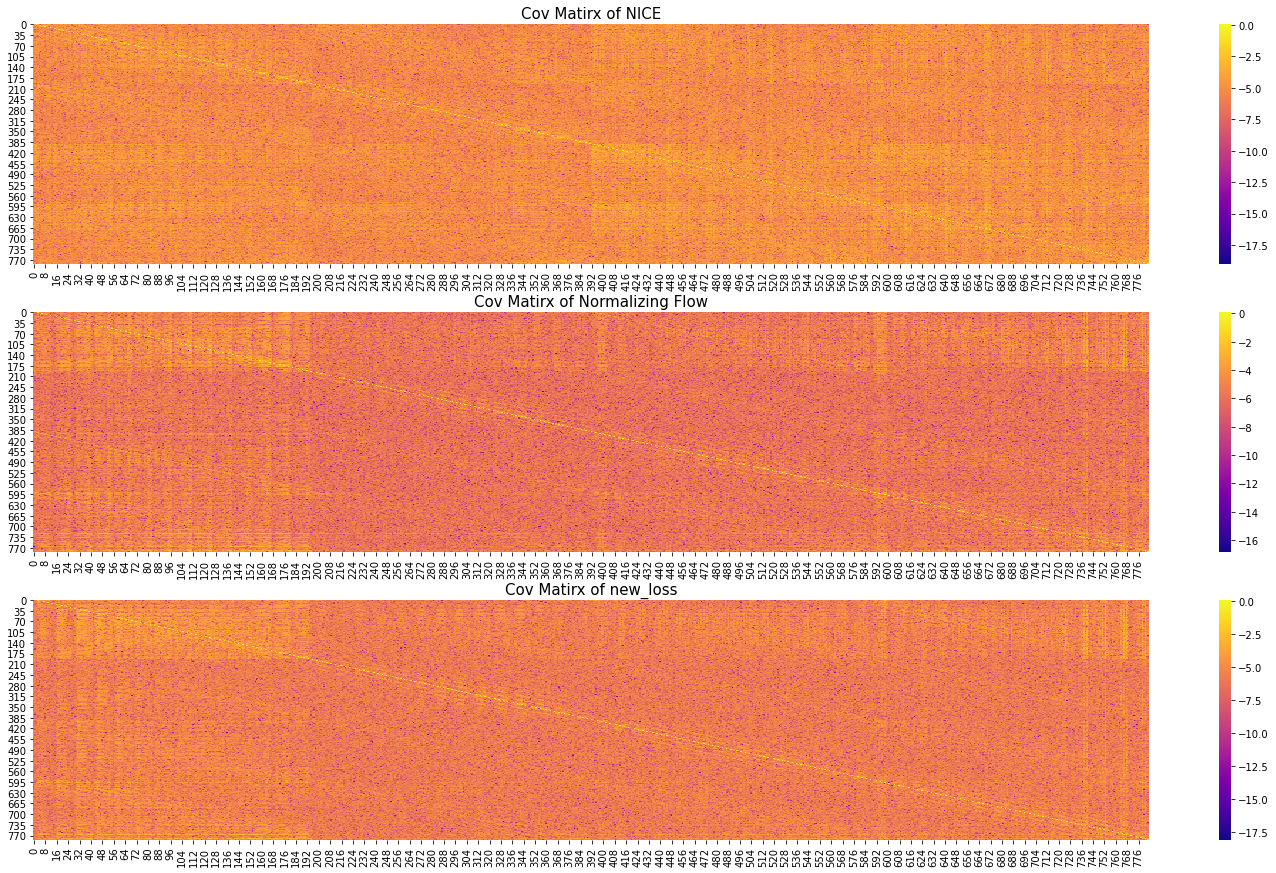

In [8]:
def plot_cov_matrices():
    _, axs = get_sub_plots()
    #sharey=True
    for i, model in enumerate(all_models):
        plot_cov_matrix(model, axs[i])
        pass
        #if i > 2: break
plot_cov_matrices()

In [9]:
#_=show_loss_histograms(all_models, score_idx=LLN_IDX, lim_left=-2.5, lim_right=-0.5)

In [10]:
#_=show_loss_histograms(all_models, score_idx=T_SCORE)#, lim_left=-2.5, lim_right=-0.5)

In [11]:
def avg_precision(data, dummy=None):
    true_class = []
    all_scores = []
    ignored_classes = [MAIN_TRAIN_CLS, STD_NORMAL_CLASS]
    
    test_len = None
    ood_cls_count = 0
    for cls, scores, _ in data:
        if cls == MAIN_TEST_CLS:
            test_len = len(scores)
        elif cls not in ignored_classes:
            ood_cls_count += 1
            
    max_ood_len = test_len // ood_cls_count
    for cls, scores, _ in data:
        if cls in ignored_classes:
            continue
            
        if cls != MAIN_TEST_CLS:
            scores = scores[:max_ood_len]
            
        all_scores.append(-scores)
        if cls == MAIN_TEST_CLS:
            true_class.append(np.zeros_like(scores))
        else:
            true_class.append(np.ones_like(scores))
    
    all_scores = np.concatenate(all_scores)
    true_class = np.concatenate(true_class)
    
    ap = average_precision_score(true_class, all_scores)
    auroc = roc_auc_score(true_class, all_scores)
    return ap, auroc

In [12]:
def plot_lln_without_vol(model, normalize, skip_gauss=False, xlim=None, ax=None):
    hist_data = []
    #plt.figure(figsize=(20, 5))
    #if model != 'iwae_no_bias':
    #    return
    
    if normalize == 'std_normalize':
        Z = all_models[model][MAIN_TRAIN_CLS][Z_IDX]
        mu_Z = Z.mean(axis=0)
        
        cov_Z = np.cov(Z-mu_Z, rowvar=False)
        cov_inv = np.linalg.inv(cov_Z)
        #sigma_Z = Z.var(axis=0)
    if normalize == 'avg_volume':
        Vol = all_models[model][MAIN_TRAIN_CLS][VOLUME_IDX]
        a = (-Vol).max()
        N = len(Vol)
        # Vol in original space is logged
        # log sum exp with the maximal a
        # a + log (1/N sum_i exp( -V(x_i) - a ) )
        avg_log_volume = -(a + np.log( np.sum( np.exp(-Vol - a) ) ) - np.log(N))
        print(f'Avg log vol: {avg_log_volume:.3f}')
        #print((-Vol - a).max())    
    
    main_train_mean = None
    main_train_std_dev = None
    
    # MAIN_TRAIN_CLS needs to come first
    classes = list(all_models[model].keys())
    classes.remove(MAIN_TRAIN_CLS)
    for cls in [MAIN_TRAIN_CLS] + classes:
        if skip_gauss and cls == STD_NORMAL_CLASS:
            continue
            
        losses = all_models[model][cls]
        if cls != STD_NORMAL_CLASS:
            if normalize == 'basic':
                bpd = losses[LLN_IDX]
            else:
                Z = losses[Z_IDX]

                if normalize == 'std_normalize':
                    #Z = (Z - mu_Z) / sigma_Z
                    Z = (Z-mu_Z) @ cov_inv
                    all_models[model][cls][STD_NORM_Z_IDX] = Z

                prior_ll = priors[model].log_prob(torch.tensor(Z).float())

                if normalize == 'avg_volume':
                    prior_ll += avg_log_volume
                elif normalize == 'add_volume':
                    prior_ll += losses[VOLUME_IDX]

                # this happens at the start for gauss
                bpd = prior_ll / (np.log(2) * additionals[model]['total_latent_dim'])

            if cls == MAIN_TRAIN_CLS:
                main_train_mean, main_train_std_dev = bpd.mean(), bpd.var() ** 0.5
            
            student_bpd = (bpd - main_train_mean) / main_train_std_dev
        else:
            # This is the Gaussian
            bpd = losses[LLN_IDX]
            mean, std_dev = bpd.mean(), bpd.var() ** 0.5
            student_bpd = (bpd - mean) / std_dev
            all_models[model][cls][STD_NORM_Z_IDX] = losses[Z_IDX]
        
        student_bpd = bpd
        hist_data.append((cls, student_bpd, student_bpd.mean()))

    ap, auroc = avg_precision(hist_data)
    show_histograms(hist_data, hide_output=True, ax=ax)
    ax.set_title(f'{model_short_to_name(model)} AP: {ap:.3f} AUROC: {auroc:.3f}', fontsize=TITLE_FONT_SIZE)
    if normalize == 'std_normalize':
        ax.set_xlabel('log pZ(std_normalize( f_inv(x) ) ) in bpd', fontsize=AXIS_FONT_SIZE)
    elif normalize == 'avg_volume':
        ax.set_xlabel(f'( log pZ( f_inv(x) ) - log sum 1 / volume(x) ) in bpd - avg log vol: {avg_log_volume:.3f}', fontsize=AXIS_FONT_SIZE)
    elif normalize == 'add_volume':
        ax.set_xlabel(f'( log pZ( f_inv(x) ) + log V(x) ) in bpd', fontsize=AXIS_FONT_SIZE)
    elif normalize == 'basic':
        ax.set_xlabel(f'log pX( x ) in bpd', fontsize=AXIS_FONT_SIZE)
    elif normalize == 'no_volume':
        ax.set_xlabel('log pZ(f_inv(x)) in bpd', fontsize=AXIS_FONT_SIZE)

    # finding good boundaries
    min_left, max_right = 10000, -10000
    alpha = 0.05
    for _, X, _ in hist_data:
        sorted_X = np.sort(X)
        N = len(X)
        x_left, x_right = sorted_X[int(N*alpha)], sorted_X[int(N*(1-alpha))]
        min_left, max_right = min(x_left, min_left), max(max_right, x_right)

    ax.set_xlim([min_left, max_right])
    return ap, auroc
    
#plot_lln_without_vol('nf', 'avg_volume', skip_gauss=False)#, xlim=pz_xlim)

In [13]:
def plot_all_llns(normalize=None, xlim=None):
    _, axs = get_sub_plots(7)
    output = ''
    for i, model in enumerate(all_models):
        ap, auroc = plot_lln_without_vol(model, skip_gauss=False, xlim=xlim, ax=axs[i], normalize=normalize)
        output += f'{model_short_to_name(model)} \tAP: {ap:.3f} auroc: {auroc:.3f} \n'
        #plot_lln_without_vol(model, skip_gauss=False, ax=axs[i], normalize=normalize)
        #if i == 1: break
    print(output)

# Likelihood as intended

NICE 	AP: 0.334 auroc: 0.166 
Normalizing Flow 	AP: 0.325 auroc: 0.117 
new_loss 	AP: 0.327 auroc: 0.128 



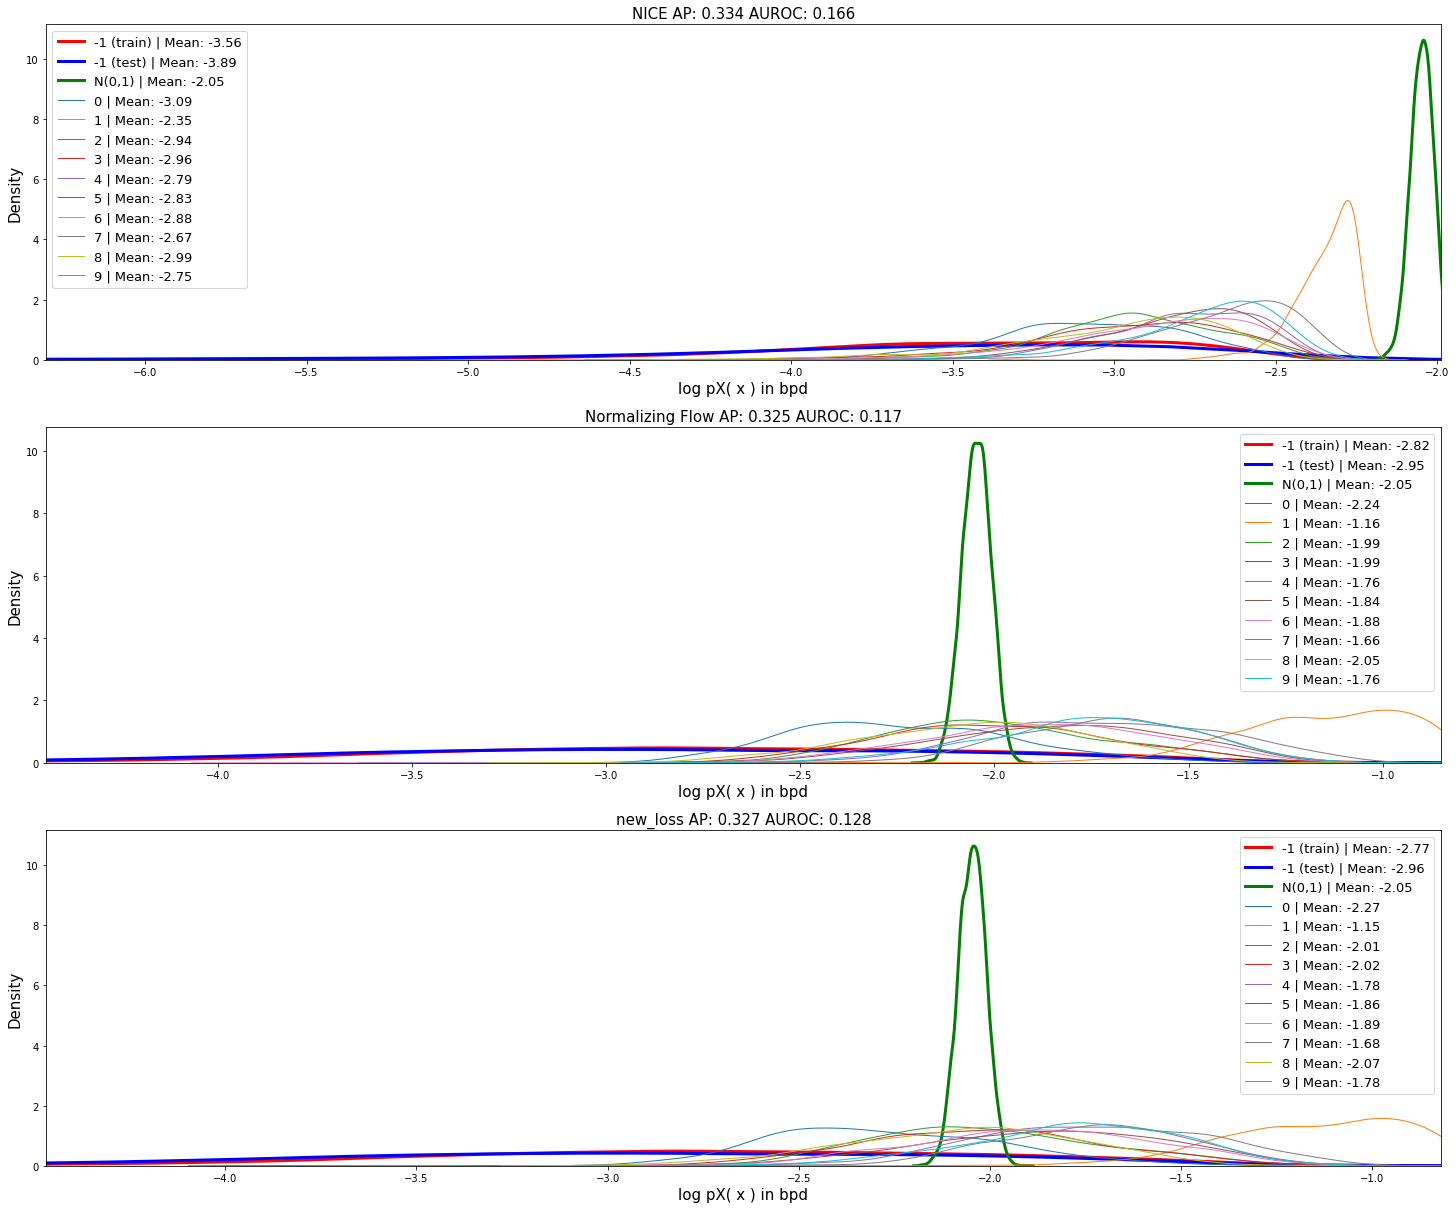

In [18]:
plot_all_llns('basic')

# Likelihood without the Volume Changing Term

In [15]:
#plot_all_llns('no_volume')

# Added the volume term for new loss

NICE 	AP: 0.334 auroc: 0.166 
Normalizing Flow 	AP: 0.325 auroc: 0.117 
new_loss 	AP: 0.327 auroc: 0.128 



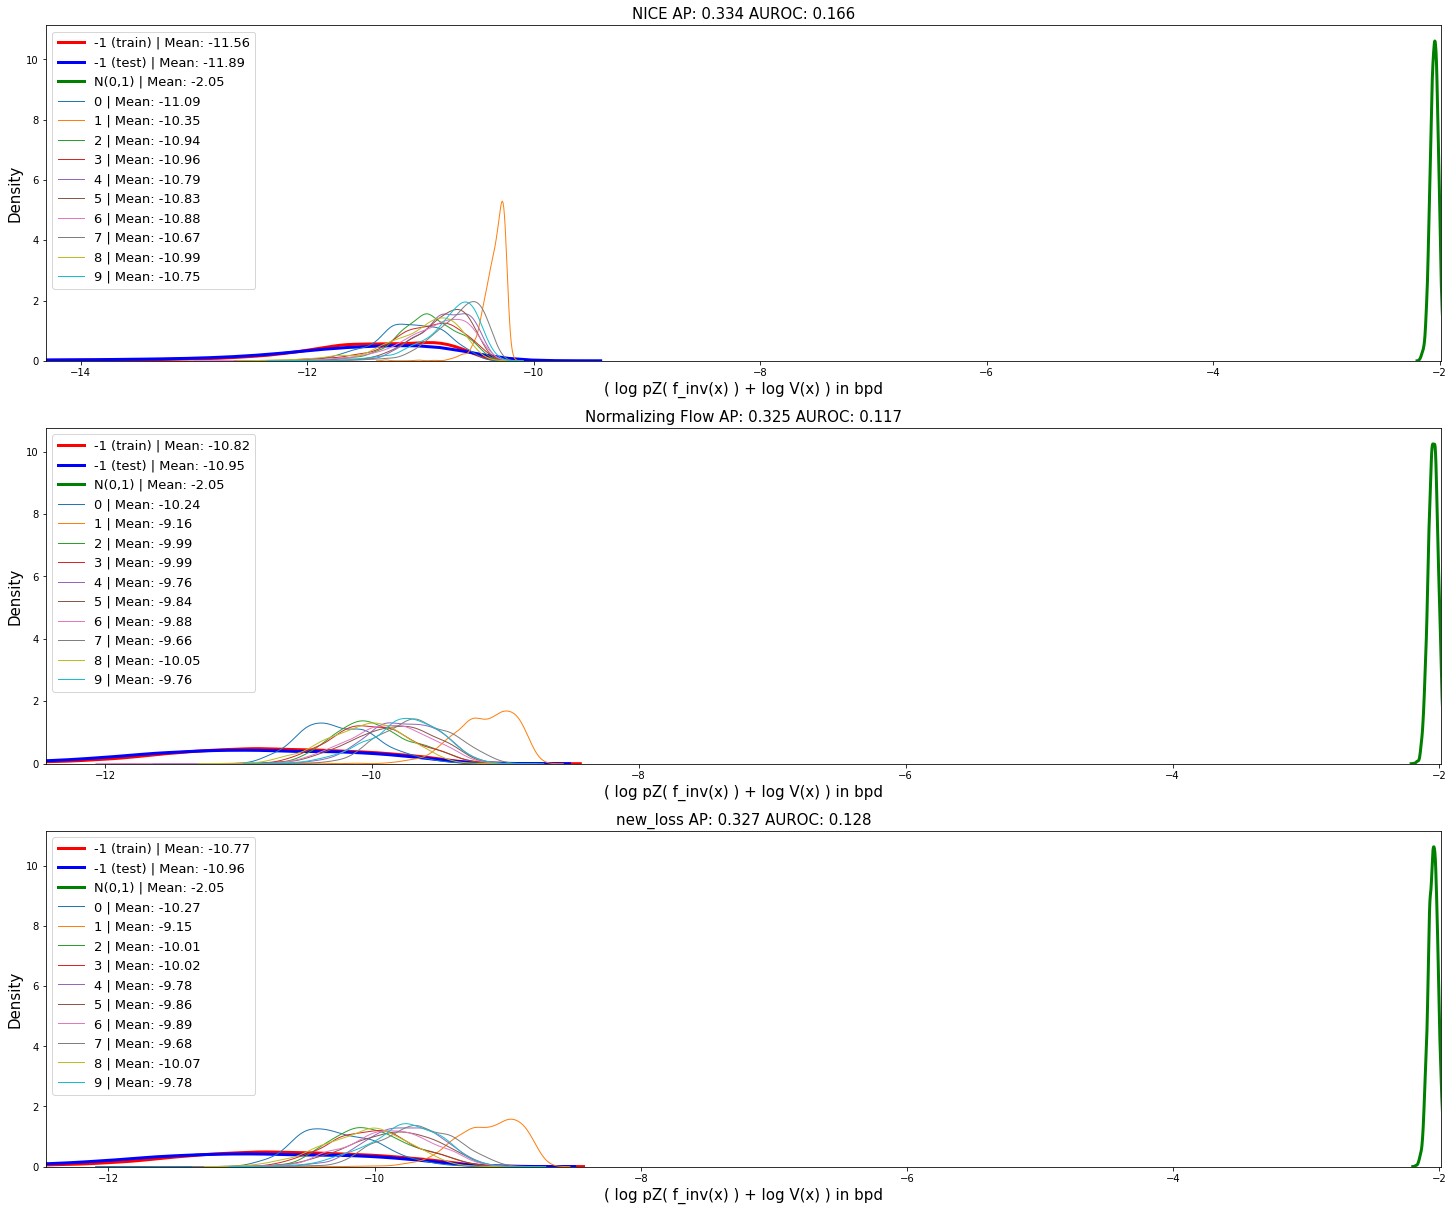

In [17]:
plot_all_llns('add_volume')

# Likelihood without Volume Changing Term, and z got normalized
Bei NF besser weil siehe Cov Matrix

In [ ]:
#plot_all_llns('std_normalize')

# Space not correct

In [19]:
from scipy.stats import kendalltau

def check_correct_space(model, group='all'):
    # group = ['all', 'training', 'ood']
    # first we put all classes in one vector
    all_z = []
    all_lln = []
    for cls, losses in all_models[model].items():
        main_cls = cls == MAIN_TRAIN_CLS or cls == MAIN_TEST_CLS
        if group == 'training' and not main_cls:
            continue
        elif group == 'ood' and main_cls:
            continue
        
        all_z.append(losses[Z_IDX])
        all_lln.append(losses[LLN_IDX])
        
    all_z = np.concatenate(all_z)
    all_lln = np.concatenate(all_lln)
    
    assert len(all_z) == len(all_lln)
    
    z_log_prob = priors[model].log_prob(torch.tensor(all_z)).numpy()
    #z_log_prob = -np.linalg.norm(all_z, axis=1)
    
    # make outputs unique, which is more correct for kendalltau (our arrays are big enough...)
    _, idcs = np.unique(z_log_prob, return_index=True)
    z_log_prob, all_lln = z_log_prob[idcs], all_lln[idcs]
    
    _, idcs = np.unique(all_lln, return_index=True)
    z_log_prob, all_lln = z_log_prob[idcs], all_lln[idcs]
    
    tau = kendalltau(z_log_prob, all_lln)
    
    print(f'{model_short_to_name(model)} and group {group}: {tau}')

    return
    
print('Small mismatches seam to occure for small numerical changes. Note: on preprocessing on GPU and here on CPU.')
print('The two-sided p-value for a hypothesis test whose null hypothesis is an absence of association, tau = 0.\n')

check_correct_space('nf', 'ood')
check_correct_space('nf', 'training')
print('--------------')
check_correct_space('nf_new_loss', 'ood')
check_correct_space('nf_new_loss', 'training')
print('--------------')
check_correct_space('continued_new_loss', 'ood')
check_correct_space('continued_new_loss', 'training')
print('--------------')
#check_correct_space('nf_new_reg_90/10', 'ood')
#check_correct_space('nf_new_reg_90/10', 'training')

Small mismatches seam to occure for small numerical changes. Note: on preprocessing on GPU and here on CPU.
The two-sided p-value for a hypothesis test whose null hypothesis is an absence of association, tau = 0.

Normalizing Flow and group ood: KendalltauResult(correlation=0.18729706936965726, pvalue=1.3590138501544317e-257)
Normalizing Flow and group training: KendalltauResult(correlation=0.14236042212164463, pvalue=0.0)
--------------


KeyError: 'nf_new_loss'

# Probability Contribution / Volume Change

In [ ]:
def show_volume_changing(model, ax):
    #plt.figure(figsize=(20, 5))
    data_shape = additionals[model]['total_latent_dim']
    
    hist_data = []
    
    for cls, losses in all_models[model].items():
        volume = losses[VOLUME_IDX] / (np.log(2) * np.prod(data_shape))
        hist_data.append((cls, volume, volume.mean()))
    
    print('sup')
    show_histograms(hist_data, ax=ax)
    ax.set_xlabel('log V(x,z) (probability contribution / volume change) in BPD', fontsize=AXIS_FONT_SIZE)
    ax.set_title(model_short_to_name(model), fontsize=TITLE_FONT_SIZE)

In [ ]:
#_, axs = get_sub_plots(6)
#for i, model in enumerate(all_models):
#    show_volume_changing(model, axs[i])

# Shapiro Wilk Test
https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test<br>
Shapiro Wilk is probably a bad idea, because we have to invert a matrix bigger than $500 \times 500$.

In [ ]:
def shapiro_wilk_a(model):
    
    gauss = torch.normal(0, 1, size=(20000, additionals[model]['total_latent_dim'])).double()
    ordered_gauss, _ = torch.sort(gauss, dim=1)
    m = ordered_gauss.mean(axis=0).numpy()
    V = np.cov(ordered_gauss, rowvar=False)
    V_inv = np.linalg.inv(V)
    C = np.linalg.norm(V_inv @ m)
    a = m.T @ V_inv / C
    return a

wilk_a_const = dict()
for model in all_models:
    wilk_a_const[model] = shapiro_wilk_a(model)

def shapiro_wilk(model, z):
    global wilk_a_const
    z = np.sort(z)
    numinator = wilk_a_const[model].T @ z
    numinator = numinator ** 2
    
    denuminator = np.var(z) * z.shape[0]
    
    return numinator / denuminator


In [ ]:
def plot_shapiro_wilk(model, ax, xlim=None, z_idx=Z_IDX):
    hist_data = []
    
    def shapiro_for_all_z_of_cls(cls):
        Z = all_models[model][cls][z_idx]
        hist_of_cls = []
        for z in Z:
            sw = shapiro_wilk(model, z)
            sw = np.log(sw)
            hist_of_cls.append(sw)
        hist_of_cls = np.array(hist_of_cls)
        return hist_of_cls
    
    train_cls_values = shapiro_for_all_z_of_cls(MAIN_TRAIN_CLS)
    
    for cls, losses in all_models[model].items():
        hist_of_cls = shapiro_for_all_z_of_cls(cls)
        studentized = (hist_of_cls - train_cls_values.mean()) / train_cls_values.var() ** 0.5
        hist_data.append((cls, studentized, studentized.mean()))

    show_histograms(hist_data, ax=ax)
    ax.set_xlabel('W of Shapiro-Wilk Test', fontsize=AXIS_FONT_SIZE)
    ax.set_title(model_short_to_name(model), fontsize=TITLE_FONT_SIZE)
    if xlim is not None:
        ax.set_xlim(xlim)

ToDo: ausprobieren nochmal std normalizen

In [ ]:
#_, axs = get_sub_plots(6)
for i, model in enumerate(all_models):
    print(f'{i} / {len(all_models)}')
    #plot_shapiro_wilk(model, axs[i], xlim=[-4, 4])
    #if i == 1: break

In [ ]:
#_, axs = get_sub_plots(6)
for i, model in enumerate(all_models):
    #plot_shapiro_wilk(model, axs[i], z_idx=STD_NORM_Z_IDX, xlim=[-4, 4])
    pass

# Kolmogorov Smirnov
https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test

In [20]:
def plot_kolmogorov_smirnov(model, ax, xlim=None, ylim=None, cdf='norm'):
    hist_data = []
    #amount_of_samples = 300
    #amount_of_samples = 100000
    #if cdf == 'main_Z':
    #    amount_of_samples = 300  # super slow
    significant_value = 0.01
    significant_percent = int(significant_value*100)
    
    def ks_test_per_class(Z, cdf_z):
        hist_of_cls = []
        for i, z in enumerate(Z):
            #ks_statistic, p_value = kstest(z, 'norm')
            ks_statistic, p_value = kstest(z, cdf_z)
            #hist_of_cls.append(p_value)
            hist_of_cls.append(ks_statistic)
            #if i > amount_of_samples: break
        return np.array(hist_of_cls)
    
    if cdf == 'main_Z':
        """Use the actual z values to compute the cdf"""
        main_Z = all_models[model][MAIN_TRAIN_CLS][Z_IDX][:500].flatten()
        main_Z.sort()
        cdf = main_Z
    
    # we also compute the ks test between all likelihoods
    p_values_std_normal = ks_test_per_class(all_models[model][STD_NORMAL_CLASS][Z_IDX], cdf)
    p_values_std_normal.sort()
    
    p_values = []
    true_class = []
    for cls, losses in all_models[model].items():
        Z = losses[Z_IDX]
        #Z = losses[STD_NORM_Z_IDX]
        
        p_values_per_sample = ks_test_per_class(Z, cdf)
        ks_statt, p_value_of_cls = kstest(p_values_per_sample, p_values_std_normal, alternative='two-sided')
        
        # ignore train class for auroc
        if cls != MAIN_TRAIN_CLS:
            p_values.append(p_values_per_sample)
            if cls == MAIN_TRAIN_CLS or cls == MAIN_TEST_CLS:
                true_class.append(np.zeros_like(p_values_per_sample))
            else:
                true_class.append(np.ones_like(p_values_per_sample))
        
        mean = p_values_per_sample.mean()
        significant = (p_values_per_sample <= significant_value).mean()
        #hist_data.append((cls, p_values_per_sample, f'Mean: {mean:.3f}| < {significant_percent}%: {significant:.3f}| ks(ks(Z), ks(N)): {p_value_of_cls:.4f}'))
        hist_data.append((cls, p_values_per_sample, f'Mean: {mean:.3f}| < {significant_percent}%: {significant*100:.1f}%'))
    
    neg_p_values, true_class = -np.concatenate(p_values), np.concatenate(true_class)
    ap, auroc = average_precision_score(true_class, neg_p_values), roc_auc_score(true_class, neg_p_values)
    
    not_main_class = np.logical_not(np.logical_or(true_class == MAIN_TRAIN_CLS, true_class == MAIN_TEST_CLS))
    correct_outliers = (-neg_p_values[not_main_class] < significant_value).mean()
    correct_inliers = (-neg_p_values[true_class == MAIN_TEST_CLS] > significant_value).mean()
    
    # significant scale for k_value
    #sig = np.sqrt(-.5 * np.log(0.05/2)) / np.sqrt(additionals[model]['total_latent_dim'])
    #plt.axvline(sig, color='k')
    ax.axvline(significant_value, color='k')
    show_histograms(hist_data, show_hist=True, ax=ax, hide_kde=True)
    ax.set_xlabel(f'Kolmogorov Smirnov Test', fontsize=AXIS_FONT_SIZE) #  (Samples: {amount_of_samples})
    ax.set_title(f'{model_short_to_name(model)} AP: {ap:.4f} AUROC: {auroc:.4f} Outliers<{significant_percent}% {correct_outliers:.3f}, '
                 f'Inliers>{significant_percent}% {correct_inliers:.3f}', fontsize=TITLE_FONT_SIZE)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    return plt, ap, auroc


In [21]:
def plot_all_ks_plots(cdf):
    _, axs = get_sub_plots(6)
    results = dict()
    for i, model in enumerate(all_models):
        print(f'Computing {i+1} / {len(all_models)}')
        _, ap, auroc = plot_kolmogorov_smirnov(model, axs[i], xlim=[-0.1, 1.1], ylim=[0, 20], cdf=cdf)
        results[model] = (ap, auroc)
        
    for model, (ap, auroc) in results.items():
        print(f'{model}\t: ap: {ap:.3f} auroc: {auroc:.3f}')

nice	: ap: 0.792 auroc: 0.706
nf	: ap: 0.502 auroc: 0.265
new_loss	: ap: 0.507 auroc: 0.273
CDF of N(0,1)


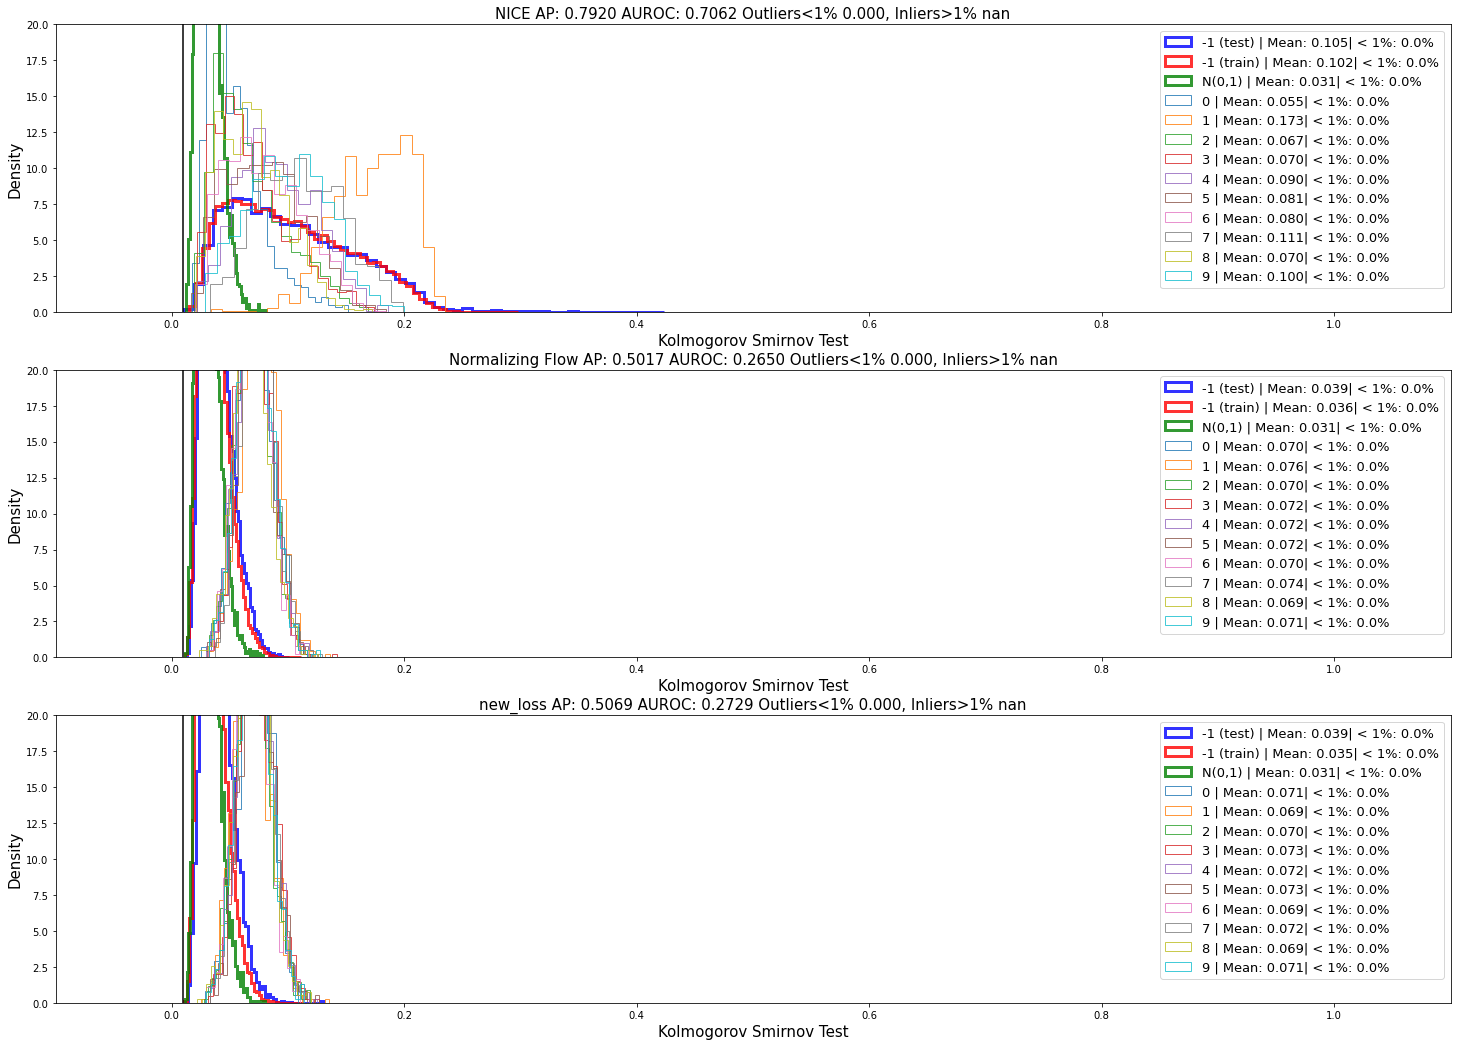

In [22]:
plot_all_ks_plots(cdf='norm')
print('CDF of N(0,1)')

nice	: ap: 0.645 auroc: 0.586
nf	: ap: 0.479 auroc: 0.255
new_loss	: ap: 0.499 auroc: 0.276
CDF of approxed by Main Class


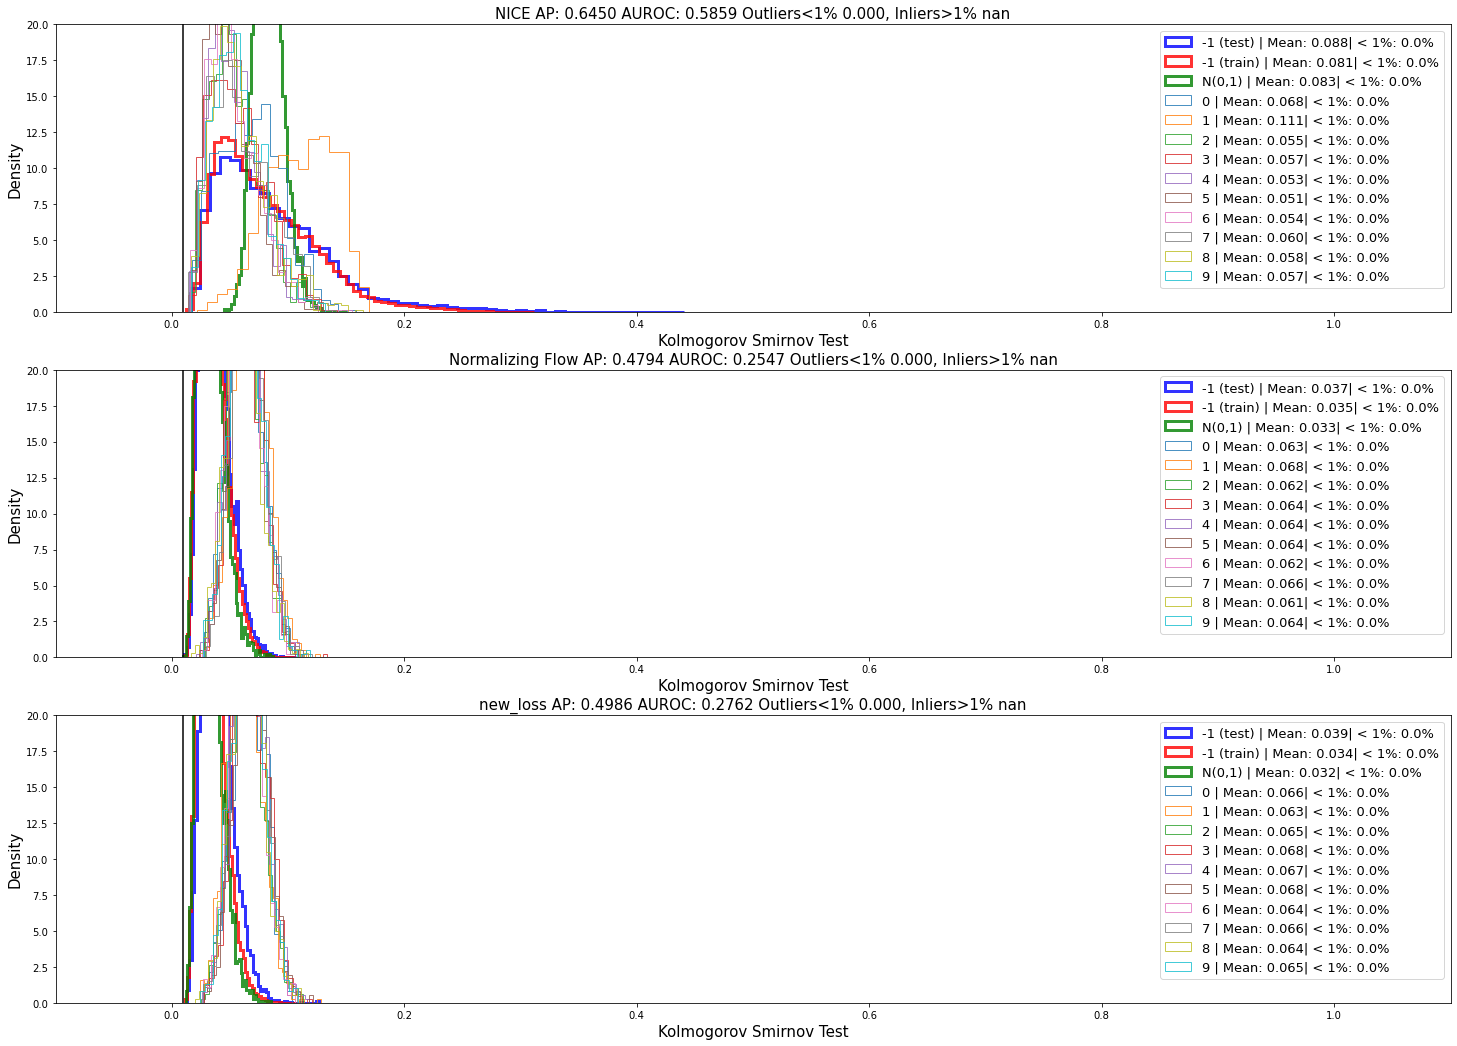

In [25]:
plot_all_ks_plots(cdf='main_Z')
print('CDF of approxed by Main Class')

# Norm
Wie viel % liegt drin

In [7]:
import numpy as np
def compute_anulus(alpha, dimensions):
    annulus_radius = np.sqrt(dimensions)
    # all but this amount of mass lies within the the annulus
    annulus_alpha = alpha
    #annulus_beta = np.sqrt( - 1/3 * np.log(annulus_alpha / 3) )    
    annulus_beta = np.sqrt( - 64 * np.log(annulus_alpha / 3) )    

    annulus_left = annulus_radius - annulus_beta
    annulus_right = annulus_radius + annulus_beta
    print(dimensions, ':', annulus_radius, annulus_left, annulus_right)
    return annulus_left, annulus_right

compute_anulus(1/100, 10)
compute_anulus(1/100, 20)
compute_anulus(1/100, 28*28)

10 : 3.1622776601683795 -15.943796724120949 22.268352044457707
20 : 4.47213595499958 -14.63393842928975 23.57821033928891
784 : 28.0 8.893925615710671 47.10607438428933


(8.893925615710671, 47.10607438428933)

In [8]:
def show_norm_histograms(model, ax, xlim=None, z_idx=Z_IDX):
    #plt.figure(figsize=(20, 5))
    hist_data = []
    
    # Plot Annulus:
    # how to compute annulus:
    # https://www.cse.unsw.edu.au/~cs4121/lectures_2019/More_randomised_algos.pdf
    annulus_radius = np.sqrt(additionals[model]['total_latent_dim'])
    # all but this amount of mass lies within the the annulus
    annulus_alpha = 1/100
    #annulus_beta = np.sqrt( - 1/3 * np.log(annulus_alpha / 3) )    
    annulus_beta = np.sqrt( - 96 * np.log(annulus_alpha / 3) )
    
    annulus_left = annulus_radius - annulus_beta
    annulus_right = annulus_radius + annulus_beta
    
    for cls, losses in all_models[model].items():
        Z = losses[z_idx]
        norm = np.linalg.norm(Z, axis=1)
        norm_mean = norm.mean()
        
        contained = np.logical_and(norm >= annulus_left, norm <= annulus_right)
        hist_data.append((cls, norm, f'Mean: {norm_mean:.2f}| Contained: {contained.mean()*100:.0f}% max: {int(Z.max())}'))
        
    show_histograms(hist_data, ax=ax)
    
    ax.axvline(annulus_right, linewidth=2, c='k', label=f'Annulus containing {100-annulus_alpha*100:.0f}% ~{int(annulus_left), int(annulus_right)}')
    ax.axvline(annulus_left, linewidth=2, c='k')
    
    ax.set_xlabel('norm of z', fontsize=AXIS_FONT_SIZE)
    ax.legend(fontsize=LEGEND_FONT_SIZE)
    ax.set_title(model_short_to_name(model), fontsize=TITLE_FONT_SIZE)
    
    #x_lim_radius = 20
    ax.set_xlim([annulus_left-10, annulus_right+40])
    if xlim is not None:
        ax.set_xlim(xlim)


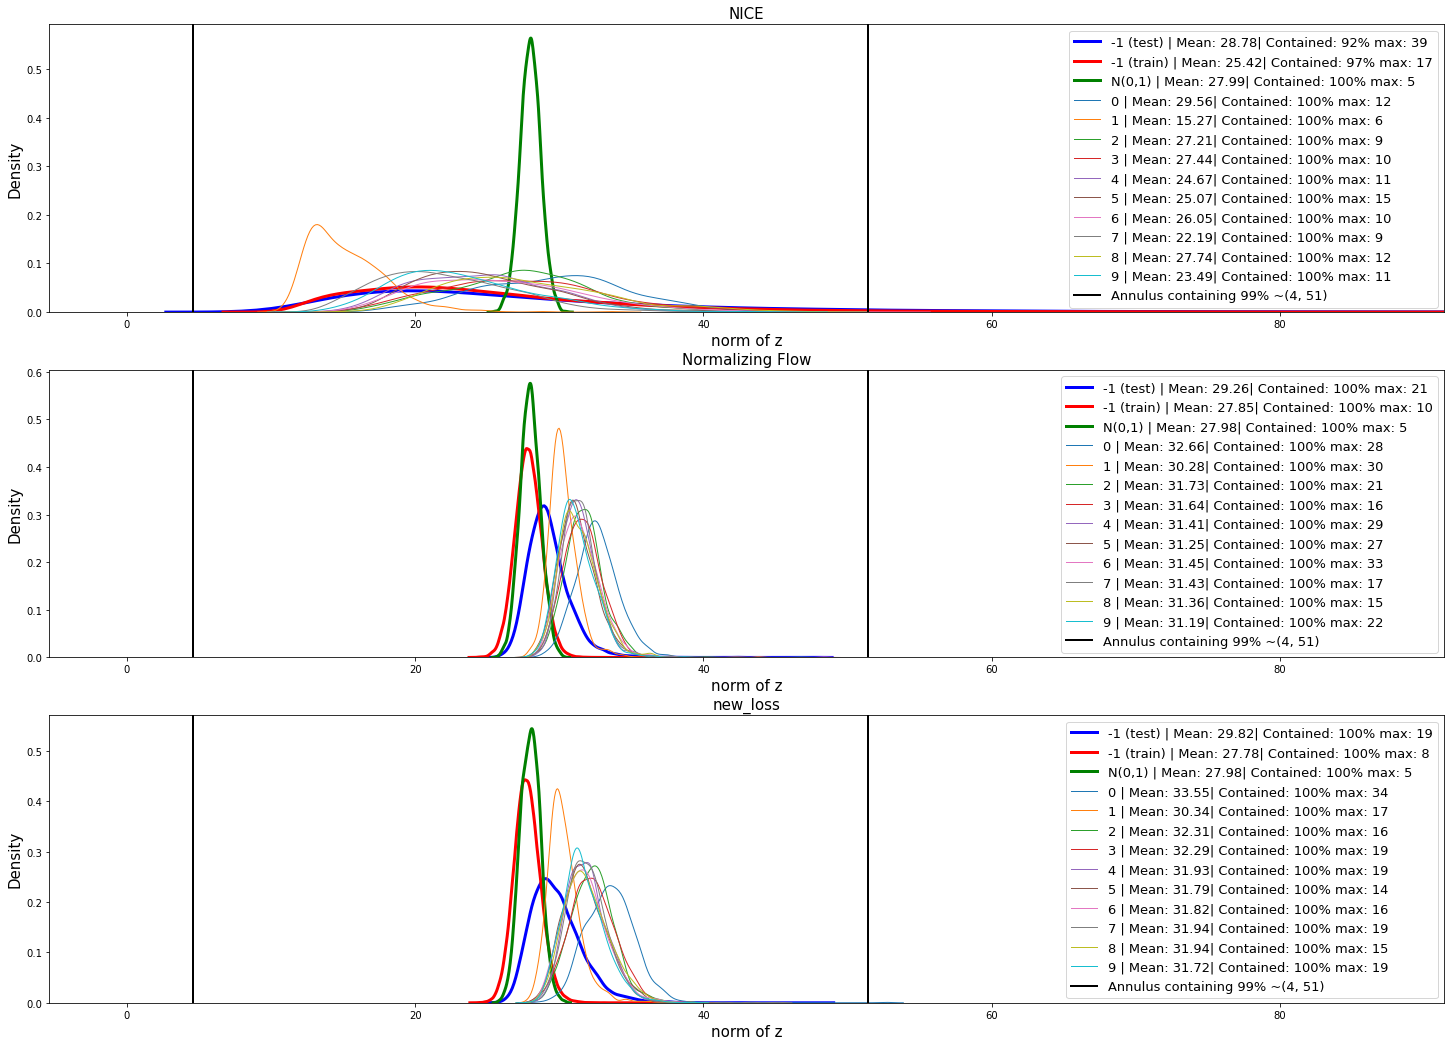

In [9]:
_, axs = get_sub_plots(6)
for i, model in enumerate(all_models):
    show_norm_histograms(model, axs[i])#, xlim=[0, 40])

In [ ]:
#_, axs = get_sub_plots(6)
#for i, model in enumerate(all_models):
#    show_norm_histograms(model, axs[i], xlim=[0, 40], z_idx=STD_NORM_Z_IDX)

# Distribution plots of a single image

In [ ]:
def show_z_histograms(model, xlim=None):
    plots_per_class = 10
    kde_kws = {'linewidth': 0.1}
    hist_data = []
    
    fig, axs = plt.subplots(len(all_models[model]), figsize=(20, 10), sharex=True)
    axs = axs.flatten()
     
    plt_nr =  0
    for cls, loss in all_models[model].items():
        Z = loss[Z_IDX]
        color = get_class_color(cls)    
        ax = axs[plt_nr]
        
        ax.axvline(Z.mean(), linewidth=2, c=color, label=f'Cls: {class_to_name(cls)} mean = {Z.mean():.5f}')
        # only show 10 per class
        Z = Z[:20] 
        for i, z in enumerate(Z):
            sns.distplot(z, hist=False, kde_kws=kde_kws, color=color, ax=ax)
        
        ax.legend(fontsize=13)
        plt_nr += 1
            
    plt.xlabel('z\'s', fontsize=AXIS_FONT_SIZE)
    plt.ylabel('Density', fontsize=15)
    plt.title(model_short_to_name(model), fontsize=TITLE_FONT_SIZE, y=len(all_models[model])+2)
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    if xlim is not None:
        plt.xlim(xlim)
    clear_output()


In [ ]:
show_z_histograms('nf', xlim=[-4,4])

In [ ]:
show_z_histograms('nf_new_loss', xlim=[-4,4])

In [ ]:
#show_z_histograms('survae', xlim=[-4,4])

In [ ]:
#show_z_histograms('conv_net', xlim=[-4,4])

In [ ]:
#show_z_histograms('iwae', xlim=[-4,4])

In [ ]:
#show_z_histograms('iwae_no_bias', xlim=[-4,4])

# All z's of one class in one kde plot

In [ ]:
def show_z_histogram(model, ax, xlim, z_idx=Z_IDX):
    #plt.figure(figsize=(20, 5))
    
    plots_per_class = 10
    interesting_classes = [STD_NORMAL_CLASS, MAIN_TRAIN_CLS, MAIN_TEST_CLS, 1, 8]
    kde_kws = dict()
    kde_kws['linewidth'] = 1.4
    
    hist_data = []
    
    for cls, loss in all_models[model].items():
        Z = loss[z_idx]
        color = get_class_color(cls)
        #out_of_bound = (np.abs(Z) > boundary).sum() / len(loss)
        # counts how many points are out of range (the mean over all axes should be correct)
        visible = np.logical_and(Z > xlim[0], Z < xlim[1])
        avg_visible = visible.mean()
        Z = Z[:50]
        sns.distplot(Z, hist=False, kde_kws=kde_kws, color=color, \
                     label=f'{get_legend_label(cls, Z.mean())} oob: {avg_visible:.6f}', ax=ax)
    
    ax.set_ylabel('Density', fontsize=AXIS_FONT_SIZE)
    ax.set_xlabel(f'z', fontsize=AXIS_FONT_SIZE)
    
    ax.legend(fontsize=LEGEND_FONT_SIZE)
    ax.set_title(model_short_to_name(model), fontsize=TITLE_FONT_SIZE)
    
    if xlim is not None:
        ax.set_xlim(xlim)
        
    clear_output()

In [ ]:
_, axs = get_sub_plots(6)
for i, model in enumerate(all_models):
    show_z_histogram(model, axs[i], xlim=[-5, 5])

In [ ]:
#_, axs = get_sub_plots(6)
#for i, model in enumerate(all_models):
#    show_z_histogram(model, axs[i], xlim=[-5, 5], z_idx=STD_NORM_Z_IDX)